# Sales Prediction Project by Mohammadreza Rafieinejad


# Import

In [ ]:
!pip install catboost
!pip install xgboost
!pip install lightgbm

In [ ]:
import numpy as np
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from scipy.stats import uniform, randint
import pickle
import warnings
warnings.filterwarnings('ignore')

Changing The Default Working Directory Path & Reading the Dataset using Pandas Command

In [ ]:
df = pd.read_csv("/content/Train.csv")


## Exploratory Data Analysis (EDA)

Getting all the unique value counts from all the columns using <span style = 'background : green'> <span style = 'color : white'>  lambda   </span></span> function

In [ ]:
df.apply(lambda x : len(x.unique()))

,0
Item_Identifier,1559
Item_Weight,416
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,4
Outlet_Location_Type,3


Checking the dataset whether it's having duplicate values or not

In [ ]:
df.duplicated().sum()

np.int64(0)

Checking for the null values of all the columns from the dataset

In [ ]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


Getting the Data types and Non-null count of all the columns from the dataset using <span style = 'background : green'><span style = 'color : white'> .info() </span> </span> statement

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Data Cleaning

Getting all the columns with "object" data type from the dataset and appending it to the list

In [ ]:
cat_col = []
for x in df.dtypes.index:
    if df.dtypes[x] == 'object':
        cat_col.append(x)
display(cat_col)

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

Removing the columns `Item_Identifier` and `Outlet_Identifier` from the list since the both columns doesn't need any cleaning

In [ ]:
cat_col.remove('Item_Identifier')
cat_col.remove('Outlet_Identifier')

Displaying the list after removing certain columns from it to verify

In [ ]:
display(cat_col)

['Item_Fat_Content',
 'Item_Type',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

Getting the unique value counts of the columns in the list

In [ ]:
for col in cat_col:
    print(col,len(df[col].unique()))

Item_Fat_Content 5
Item_Type 16
Outlet_Size 4
Outlet_Location_Type 3
Outlet_Type 4


Checking the value counts of the columns from the list and displaying it column wise

In [ ]:
for col in cat_col:
    print(col)
    print(df[col].value_counts(),'\n')
    print('-'*55)

Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64 

-------------------------------------------------------
Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64 

-------------------------------------------------------
Outlet_Size
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64 

-------------------------------------------------------
Outlet_Location_Type
Outlet_Location_Type
Tier 3    3350
Tier 2  

Getting the null values from the `Item_Weight` column for the null value treatment process and displaying the Dataset with null values in the `Item_Weight` column

In [ ]:
miss_bool = df['Item_Weight'].isnull()
Item_Weight_Null = df[df['Item_Weight'].isnull()]
display(Item_Weight_Null)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
18,DRI11,NaN,Low Fat,0.034238,Hard Drinks,113.2834,OUT027,1985,Medium,Tier 3,Supermarket Type3,2303.6680
21,FDW12,NaN,Regular,0.035400,Baking Goods,144.5444,OUT027,1985,Medium,Tier 3,Supermarket Type3,4064.0432
23,FDC37,NaN,Low Fat,0.057557,Baking Goods,107.6938,OUT019,1985,Small,Tier 1,Grocery Store,214.3876
29,FDC14,NaN,Regular,0.072222,Canned,43.6454,OUT019,1985,Small,Tier 1,Grocery Store,125.8362
...,...,...,...,...,...,...,...,...,...,...,...,...
8485,DRK37,NaN,Low Fat,0.043792,Soft Drinks,189.0530,OUT027,1985,Medium,Tier 3,Supermarket Type3,6261.8490
8487,DRG13,NaN,Low Fat,0.037006,Soft Drinks,164.7526,OUT027,1985,Medium,Tier 3,Supermarket Type3,4111.3150
8488,NCN14,NaN,Low Fat,0.091473,Others,184.6608,OUT027,1985,Medium,Tier 3,Supermarket Type3,2756.4120
8490,FDU44,NaN,Regular,0.102296,Fruits and Vegetables,162.3552,OUT019,1985,Small,Tier 1,Grocery Store,487.3656


Identifying the unique value counts in `Item_Identifier` column from the `Item_Weight` null value dataset

In [ ]:
Item_Weight_Null['Item_Identifier'].value_counts()

,count
Item_Identifier,
FDP11,2
FDA36,2
FDQ13,2
FDG02,2
FDX03,2
...,...
FDM44,1
FDZ48,1
FDK41,1


Getting the mean values of the `Item_Weight` with respect to `Item_Identifier` column of the dataset using <span style = 'background : green'><span style = 'color : white'> Pivot Table </span> </span> function

In [ ]:
Item_Weight_Mean = df.pivot_table(values = 'Item_Weight', index = 'Item_Identifier')
display(Item_Weight_Mean)

,Item_Weight
Item_Identifier,
DRA12,11.600
DRA24,19.350
DRA59,8.270
DRB01,7.390
DRB13,6.115
...,...
NCZ30,6.590
NCZ41,19.850
NCZ42,10.500


Getting the unique value counts from `Outlet_Size` column from the dataset

In [ ]:
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


Checking out for the null value counts from the `Outlet_Size` column from the dataset

In [ ]:
df['Outlet_Size'].isnull().sum()

np.int64(2410)

Getting the null values from the `Outlet_Size` column for the null value treatment process and displaying the Dataset with null values in the `Outlet_Size` column

In [ ]:
Outlet_Size_Null = df[df['Outlet_Size'].isna()]
display(Outlet_Size_Null)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350
25,NCD06,13.000,Low Fat,0.099887,Household,45.9060,OUT017,2007,NaN,Tier 2,Supermarket Type1,838.9080
28,FDE51,5.925,Regular,0.161467,Dairy,45.5086,OUT010,1998,NaN,Tier 3,Grocery Store,178.4344
...,...,...,...,...,...,...,...,...,...,...,...,...
8502,NCH43,8.420,Low Fat,0.070712,Household,216.4192,OUT045,2002,NaN,Tier 2,Supermarket Type1,3020.0688
8508,FDW31,11.350,Regular,0.043246,Fruits and Vegetables,199.4742,OUT045,2002,NaN,Tier 2,Supermarket Type1,2587.9646
8509,FDG45,8.100,Low Fat,0.214306,Fruits and Vegetables,213.9902,OUT010,1998,NaN,Tier 3,Grocery Store,424.7804
8514,FDA01,15.000,Regular,0.054489,Canned,57.5904,OUT045,2002,NaN,Tier 2,Supermarket Type1,468.7232


Getting the value counts of `Outlet_Type` from the `Outlet_Size` null dataset

In [ ]:
Outlet_Size_Null['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,1855
Grocery Store,555


Grouping by `Outlet_Type` and `Outlet_Size` with the aggregate function of size of the `Outlet_Type` column values

In [ ]:
df.groupby(['Outlet_Type','Outlet_Size']).agg({'Outlet_Type':[np.size]})

Outlet_Type
                                     size
Outlet_Type       Outlet_Size            
Grocery Store     Small               528
Supermarket Type1 High                932
                  Medium              930
                  Small              1860
Supermarket Type2 Medium              928
Supermarket Type3 Medium              935

Checking for the null values of all the columns from the dataset after missing value treatment

In [ ]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


Getting the unique value counts from the `Item_Fat_Content` column

In [ ]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


After seeing the unique value counts from the `Item_Fat_Content` column, there have been some mistyping occured like the same categories were typed under different names. For further processing, all the mistypings are corrected and named under a single category. Checking out for the value counts of `Item_Fat_Content` column

In [ ]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF' : 'Low Fat', 'low fat' : 'Low Fat', 'reg' : 'Regular'})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


Adding new column `New_Item_Type` to the dataset by getting the first two characters from the `Item_Identifier` column which represents the category of the item and getting the value counts of the `New_Item_Type` column

In [ ]:
df['New_Item_Type'] = df['Item_Identifier'].apply(lambda x : x[:2])
df['New_Item_Type'].value_counts()

,count
New_Item_Type,
FD,6125
NC,1599
DR,799


As the `New_Item_Type` column has values which is subjected to categories for better understanding, replacing the codes with meaningful categorical item name and getting the value counts of `New_Item_Type` column

In [ ]:
df['New_Item_Type'] = df['New_Item_Type'].replace({'FD' : 'Food', 'NC' : 'Non-Consumables', 'DR' : 'Drinks'})
df['New_Item_Type'].value_counts()

,count
New_Item_Type,
Food,6125
Non-Consumables,1599
Drinks,799


Grouping by `New_Item_Type` and `Item_Fat_Content` with the aggregate function of size of the `Outlet_Type` column values

In [ ]:
df.groupby(['New_Item_Type','Item_Fat_Content']).agg({'Outlet_Type':[np.size]})

Outlet_Type
                                        size
New_Item_Type   Item_Fat_Content            
Drinks          Low Fat                  728
                Regular                   71
Food            Low Fat                 3190
                Regular                 2935
Non-Consumables Low Fat                 1599

From the above output its clear that Non-Consumable type from `New_Item_Type` column is mapped to Low Fat category in `Item_Fat_Content` column. So marking it as Non-Edible in `Item_Fat_Content` column

In [ ]:
df.loc[df['New_Item_Type'] == 'Non-Consumables','Item_Fat_Content'] = 'Non-Edible'
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3918
Regular,3006
Non-Edible,1599


Getting all the unique value from `Outlet_Establishment_Year` column from the dataset

In [ ]:
df['Outlet_Establishment_Year'].unique()

array([1999, 2009, 1998, 1987, 1985, 2002, 2007, 1997, 2004])

The `Outlet_Establishment_Year` column from the dataset has no significance on its own so calculating the years of outlet established until this year and adding it as `Outlet_Years` column to the dataset

In [ ]:
curr_time = datetime.datetime.now()
df['Outlet_Years'] = 2013 - df['Outlet_Establishment_Year']

## Data Visualization

Plotting the Bar Graph with count of `Item_Fat_Content`  and confirm that there are no null values and identify all unique values from the `Item_Fat_Content` and saving the PNG File

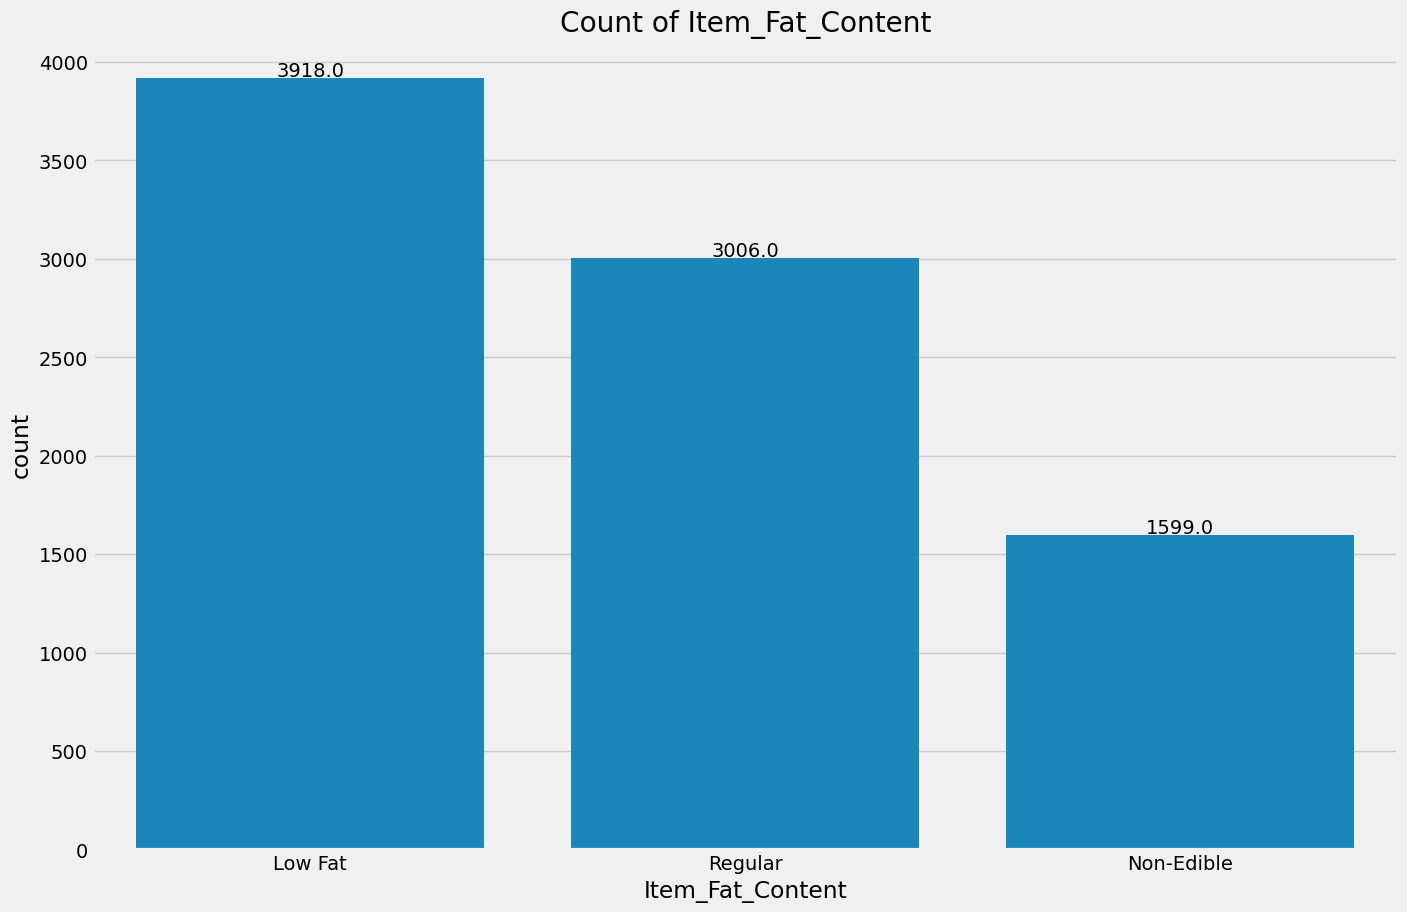

In [ ]:
plt.rcParams['figure.figsize'] = 15,10
plt.style.use('fivethirtyeight')
plot = sns.countplot(x = df['Item_Fat_Content'])
for p in plot.patches:
    plot.annotate(p.get_height(),(p.get_x() + p.get_width() / 2.0,p.get_height()),
                 ha = 'center',va = 'center',xytext = (0,5),textcoords = 'offset points')
plt.title('Count of Item_Fat_Content')
plt.savefig('Count of Item_Fat_Content.png')
plt.show()

Plotting the Bar Graph with count of `Item_Type`  and confirm that there are no null values and identify all unique values from the `Item_Type` and saving the PNG File

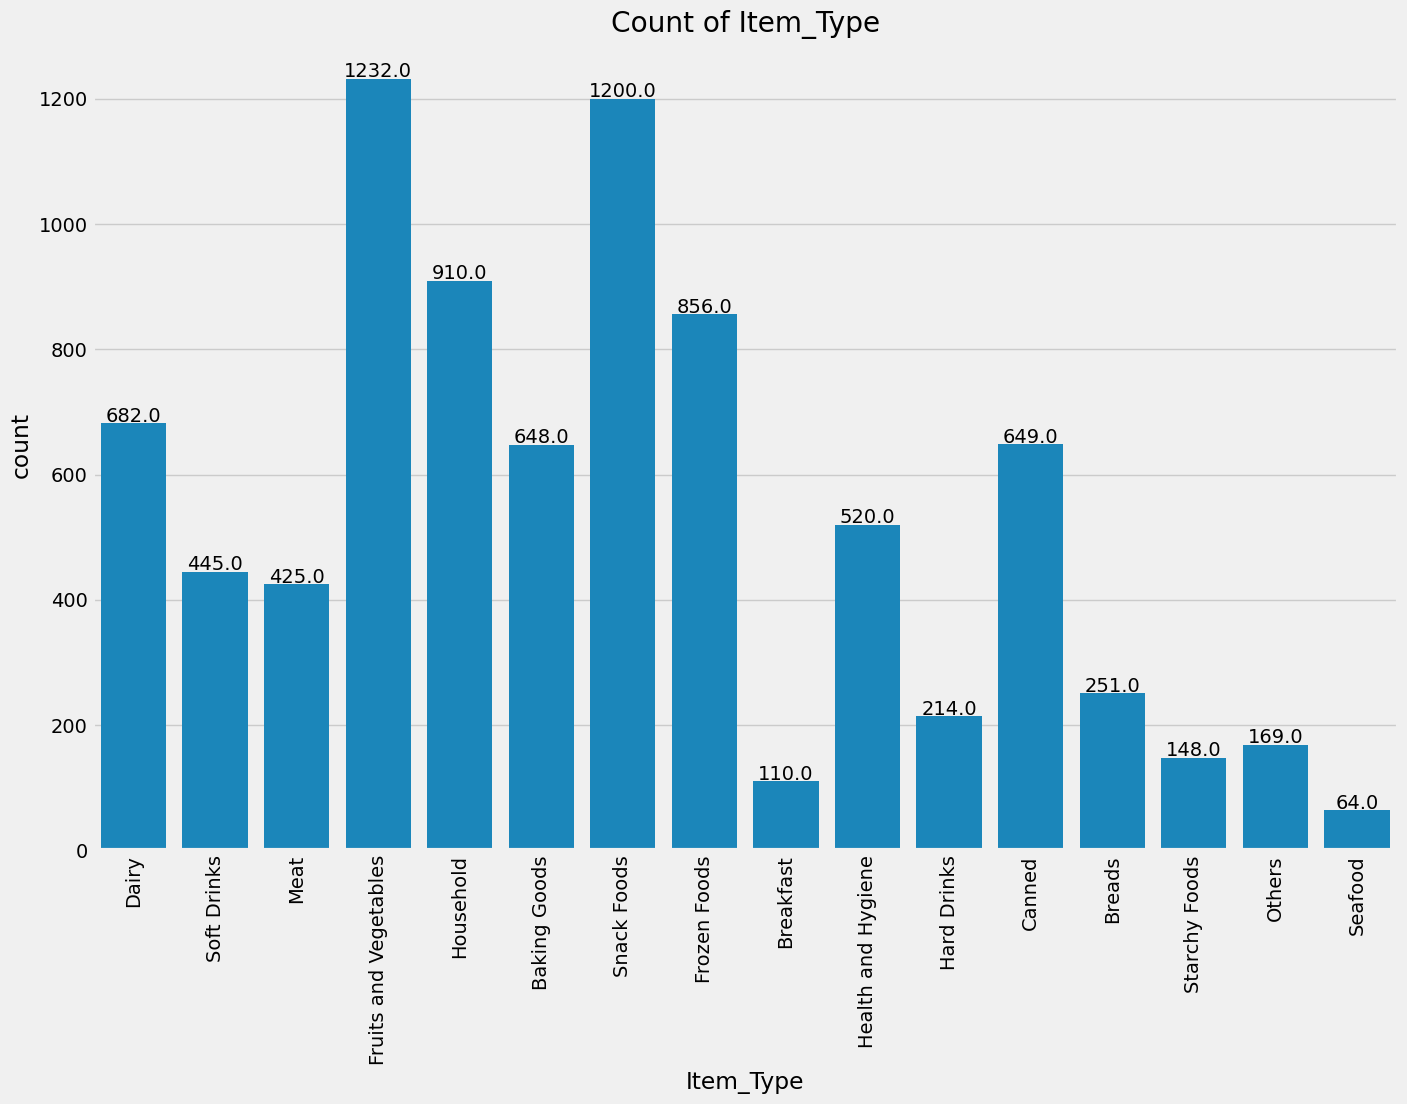

In [ ]:
plot = sns.countplot(x = df['Item_Type'])
for p in plot.patches:
    plot.annotate(p.get_height(),(p.get_x() + p.get_width() / 2.0,p.get_height()),
                 ha = 'center',va = 'center',xytext = (0,5),textcoords = 'offset points')
plt.xticks(rotation = 90)
plt.title('Count of Item_Type')
plt.savefig('Count of Item_Type.png')
plt.show()

Plotting the Bar Graph with count of `Outlet_Establishment_Year`  and confirm that there are no null values and identify all unique values from the `Outlet_Establishment_Year` and saving the PNG File

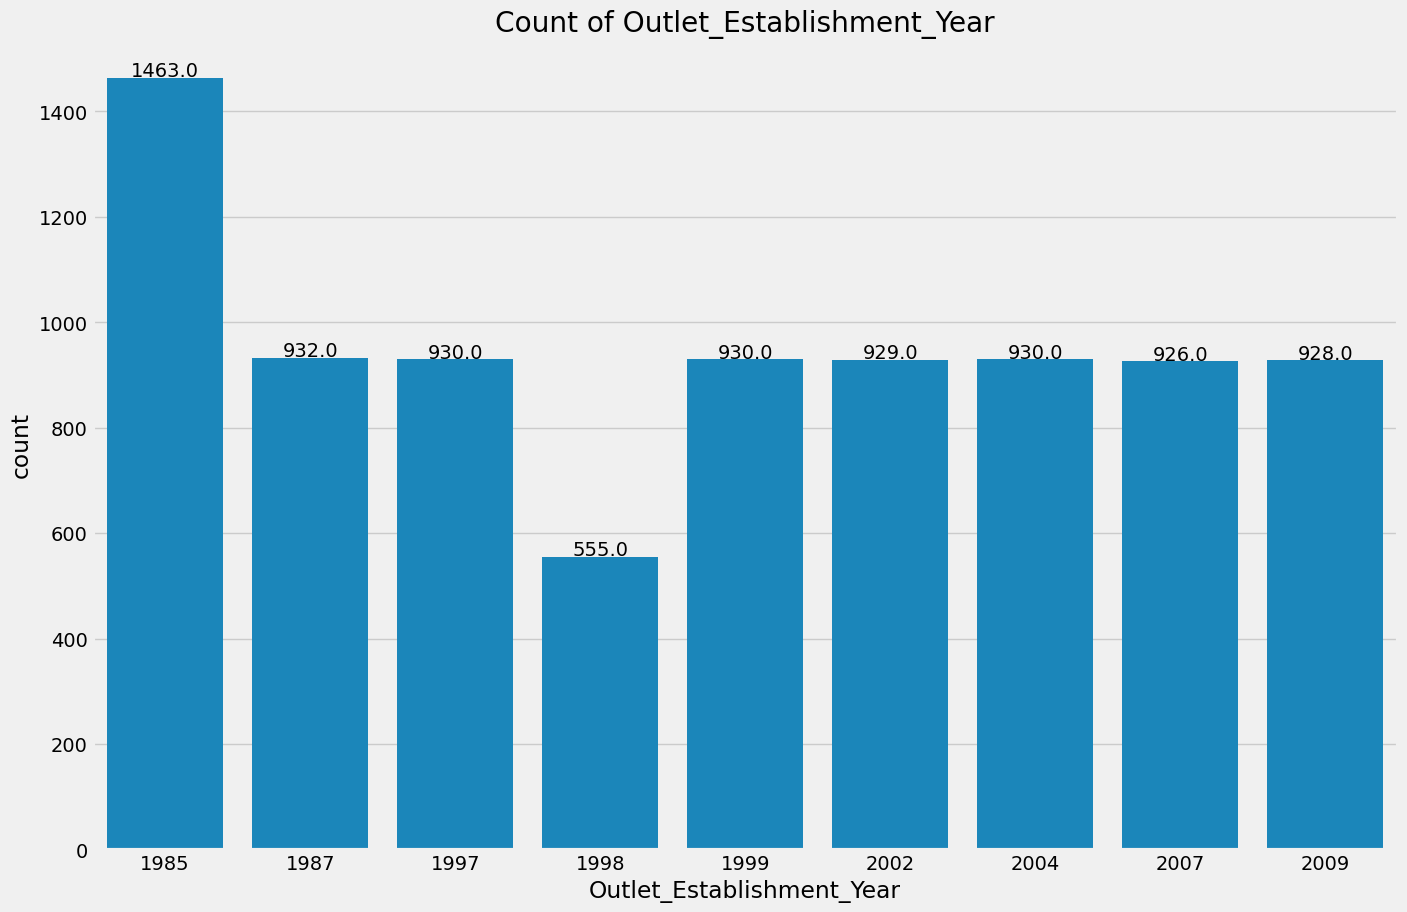

In [ ]:
plot = sns.countplot(x = df['Outlet_Establishment_Year'])
for p in plot.patches:
    plot.annotate(p.get_height(),(p.get_x() + p.get_width() / 2.0,p.get_height()),
                 ha = 'center',va = 'center',xytext = (0,5),textcoords = 'offset points')
plt.title('Count of Outlet_Establishment_Year')
plt.savefig('Count of Outlet_Establishment_Year.png')
plt.show()

Plotting the Bar Graph with count of `Outlet_Location_Type`  and confirm that there are no null values and identify all unique values from the `Outlet_Location_Type` and saving the PNG File

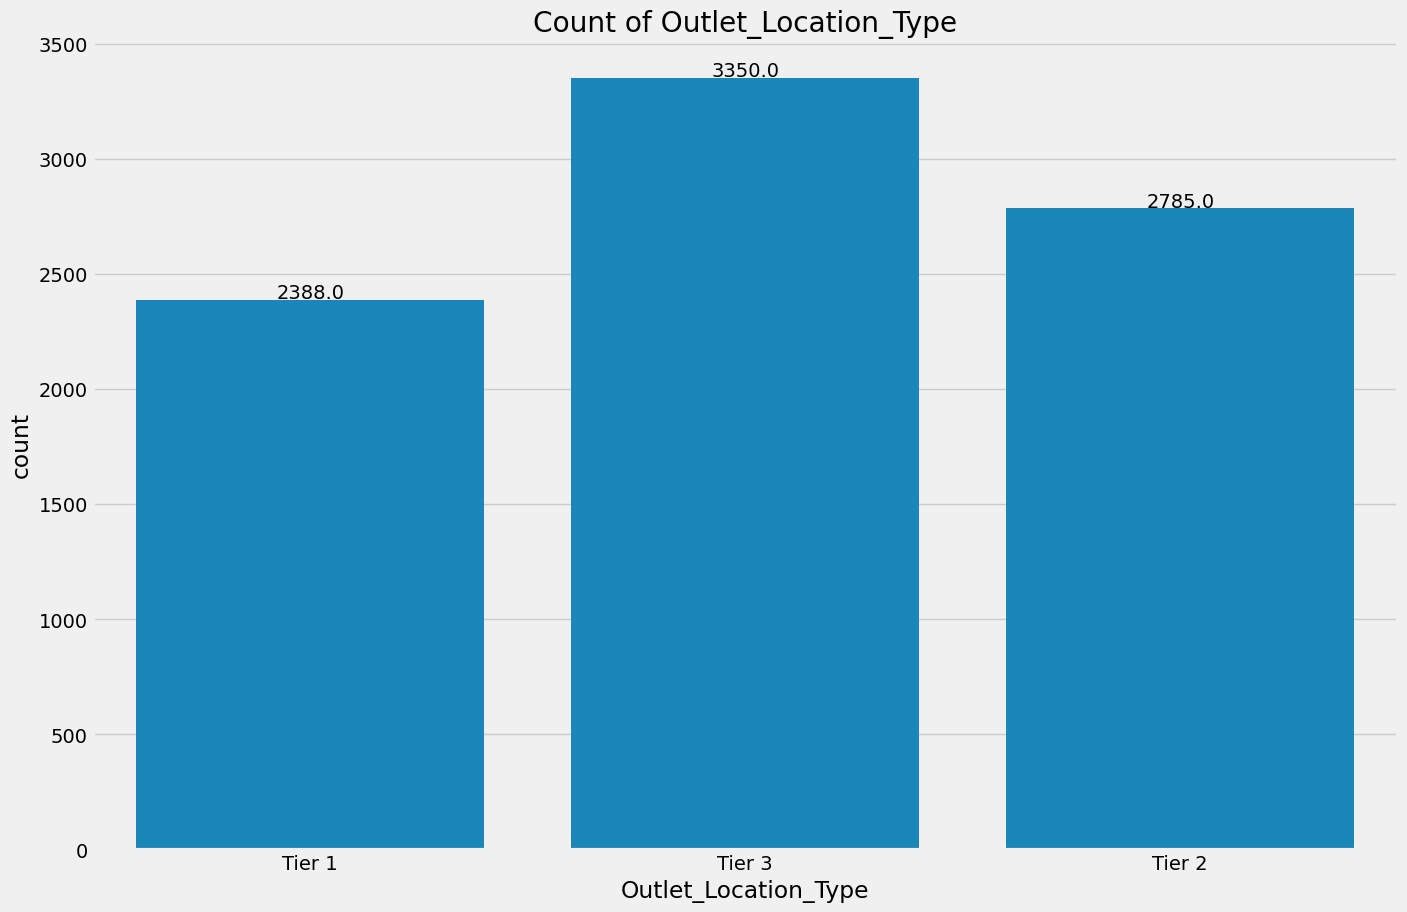

In [ ]:
plot = sns.countplot(x = df['Outlet_Location_Type'])
for p in plot.patches:
    plot.annotate(p.get_height(),(p.get_x() + p.get_width() / 2.0,p.get_height()),
                 ha = 'center',va = 'center',xytext = (0,5),textcoords = 'offset points')
plt.title('Count of Outlet_Location_Type')
plt.savefig('Count of Outlet_Location_Type.png')
plt.show()

Plotting the Bar Graph with count of `Outlet_Size`  and confirm that there are no null values and identify all unique values from the `Outlet_Size` and saving the PNG File

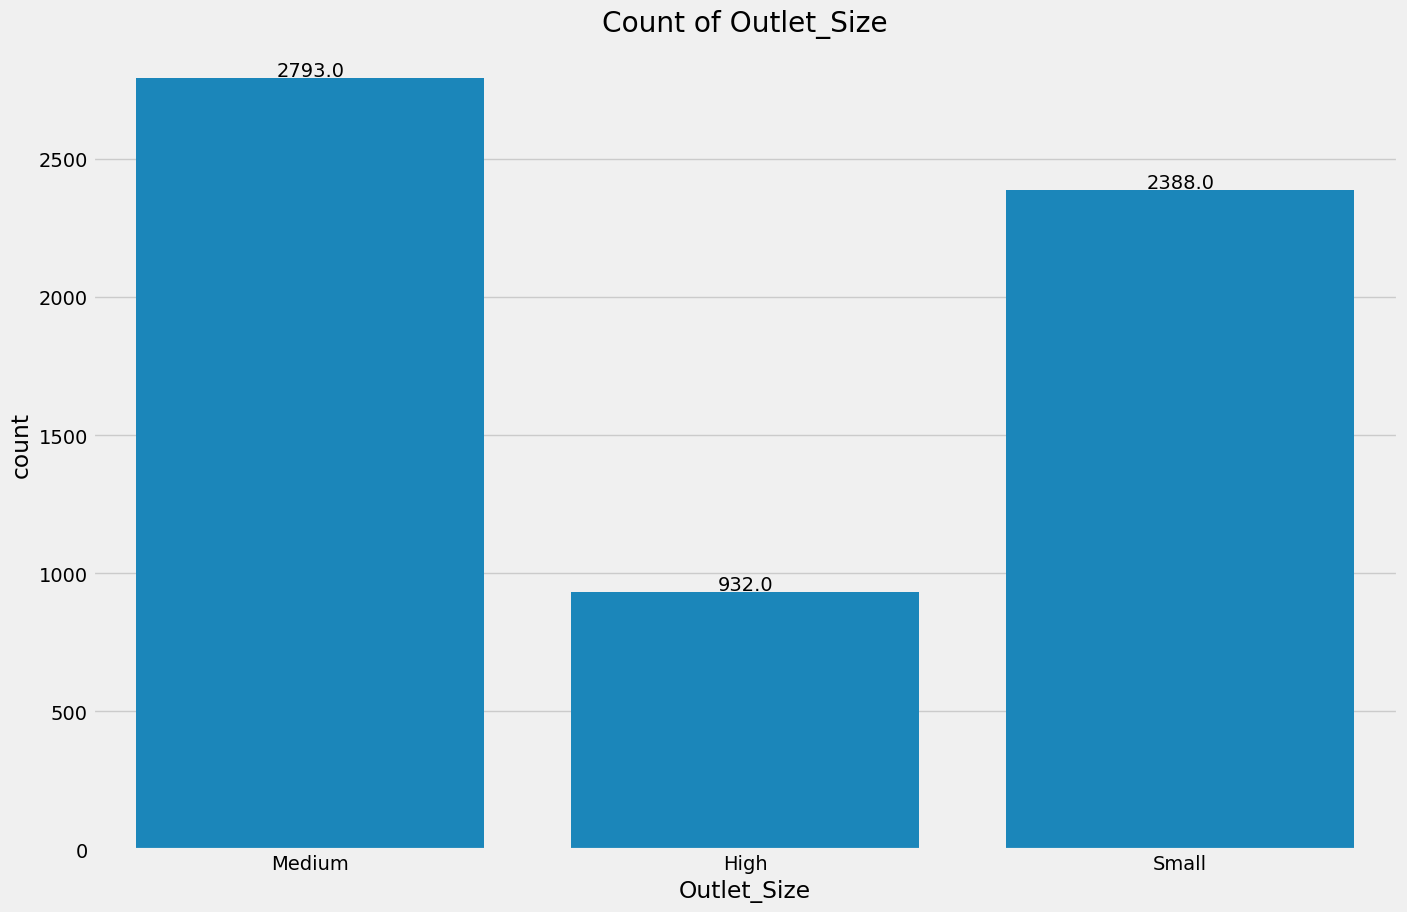

In [ ]:
plot = sns.countplot(x = df['Outlet_Size'])
for p in plot.patches:
    plot.annotate(p.get_height(),(p.get_x() + p.get_width() / 2.0,p.get_height()),
                 ha = 'center',va = 'center',xytext = (0,5),textcoords = 'offset points')
plt.title('Count of Outlet_Size')
plt.savefig('Count of Outlet_Size.png')
plt.show()

Plotting the Bar Graph with count of `Outlet_Type`  and confirm that there are no null values and identify all unique values from the `Outlet_Type` and saving the PNG File

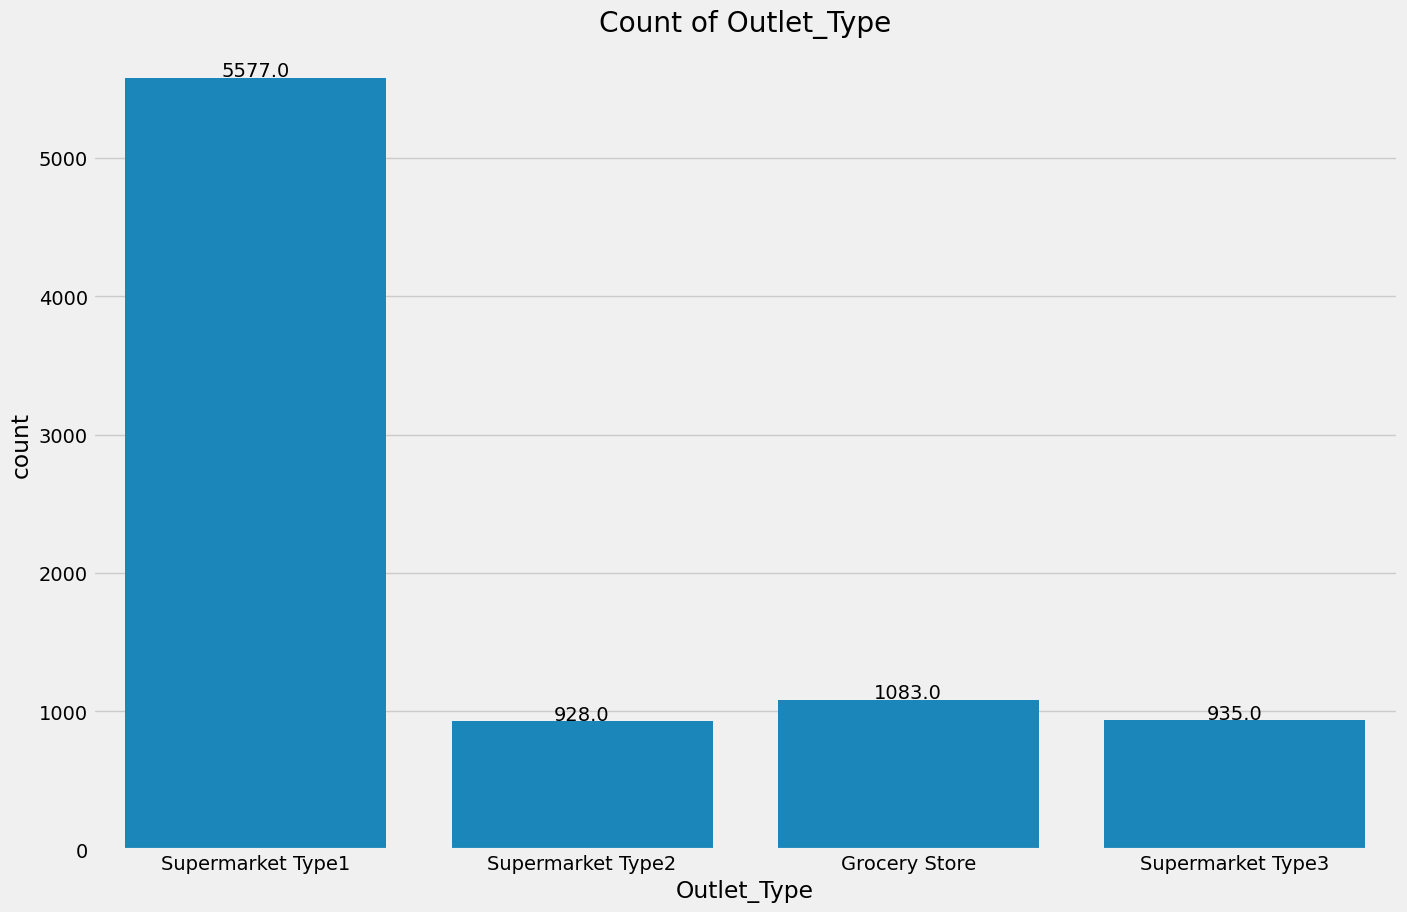

In [ ]:
plot = sns.countplot(x = df['Outlet_Type'])
for p in plot.patches:
    plot.annotate(p.get_height(),(p.get_x() + p.get_width() / 2.0,p.get_height()),
                 ha = 'center',va = 'center',xytext = (0,5),textcoords = 'offset points')
plt.title('Count of Outlet_Type')
plt.savefig('Count of Outlet_Type.png')
plt.show()

Visualizing the data distribution of the `Item_weight` column against the density distribution using Seaborn Distplot and saving the PNG file

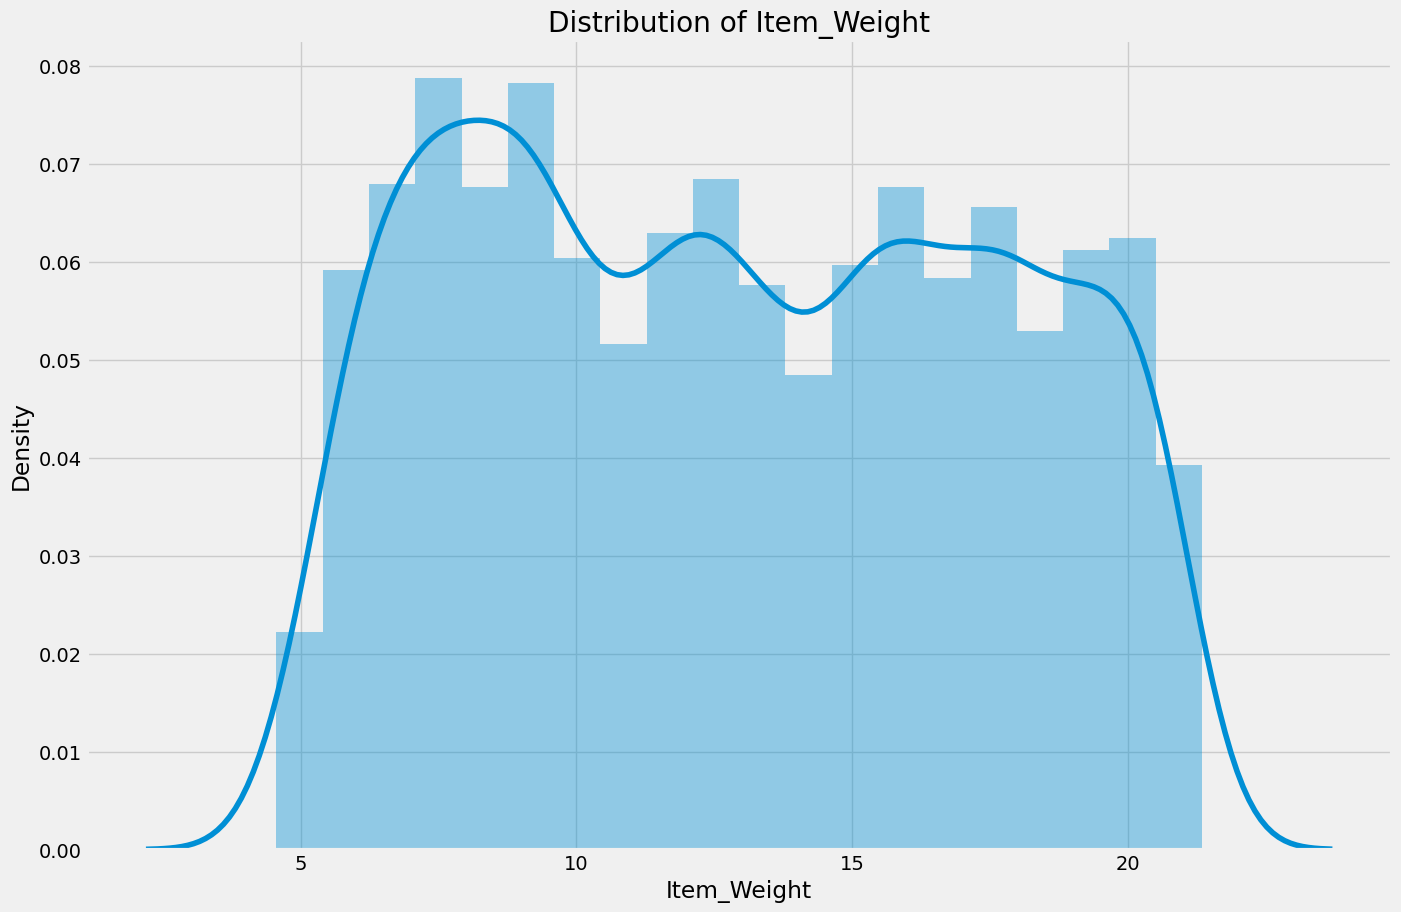

In [ ]:
sns.distplot(df['Item_Weight'],bins = 20)
plt.title('Distribution of Item_Weight')
plt.savefig('Distribution of Item_Weight.png')
plt.show()

Getting the Correlation Values from all the numeric columns from the dataset using Seaborn Heatmap & saving the PNG File

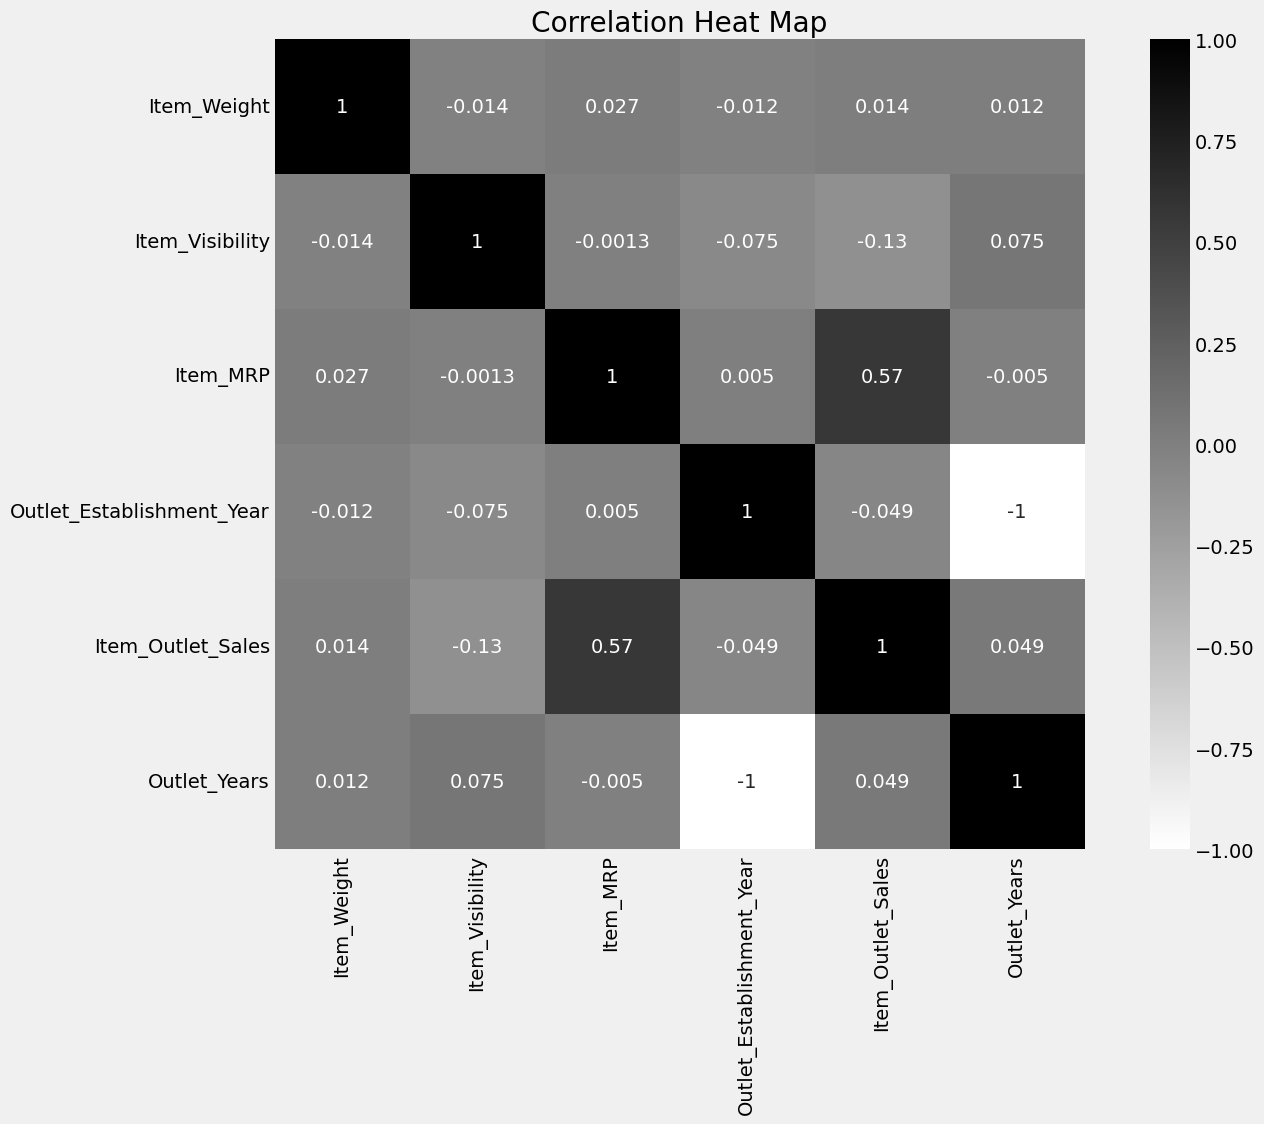

In [ ]:
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),cmap = 'binary', cbar = True, annot = True, square = True)
plt.title('Correlation Heat Map')
plt.savefig('Correlation Heat Map.png')
plt.show()

## Data Preprocessing

Getting the data types of all the columns to find out the "object" data types columns for preprocessing before assigning it to dependent variable and independent variable

In [ ]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


Assigning the dependent and independent variable

In [ ]:
x = df.drop(['Item_Identifier','Outlet_Identifier','Outlet_Establishment_Year','Item_Outlet_Sales'],axis=1)
y=df['Item_Outlet_Sales']

## Model Fitting

Splitting the dependent variable & independent variable into training and test dataset using  <span style = 'background : green'><span style = 'color : white'> train test split </span> </span>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target = "Item_Outlet_Sales"
X = df.drop(columns=[target, "Item_Identifier", "Outlet_Identifier", "Outlet_Establishment_Year"])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

num_cols = ["Item_Weight", "Item_Visibility", "Item_MRP", "Outlet_Years"]
cat_cols = ["Item_Fat_Content", "Item_Type", "Outlet_Size",
            "Outlet_Location_Type", "Outlet_Type", "New_Item_Type"]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),   # جایگزین سلول ۳۲ و ۵۶
        ("scaler", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),  # جایگزین سلول ۴۸
        ("onehot", OneHotEncoder(handle_unknown="ignore")),    # جایگزین سلول‌های ۹۴/۹۸/۱۰۰
    ]), cat_cols),
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
pipe_cb = evaluate("CatBoost", CatBoostRegressor(verbose=0, random_state=42))

cat = CatBoostRegressor(learning_rate = 0.08941885942788719, max_depth = 2, n_estimators = 109,
                        subsample = 0.6676443346250142, verbose = 0)
cat.fit(X_train, y_train, cat_features=cat_cols)
predictions = cat.predict(X_test)
print('R2 score : ',r2_score(y_test,predictions))

CatBoost           R2=0.5662 | RMSE=1102.26 | MAE=766.97


CatBoostError: Invalid type for cat_feature[non-default value idx=0,feature_idx=5]=nan : cat_features must be integer or string, real number values and NaN values should be converted to string.

Defining the function for the ML algorithm and fitting it with the passing dependent and independent variable, predicting the dependent variable using algorithm with independent variable. With using  <span style = 'background : green'><span style = 'color : white'> cross val score [Cross Validation] </span> </span> process getting the Model Report with cv_score using "neg_mean_squared_error" as scoring and also getting the absolute average mean of cv_score. After that using  <span style = 'background : green'><span style = 'color : white'> cross val score [Cross Validation] </span> </span> process, getting the cv_score as R2 score using default scoring parameter and also again getting the mean value of cv_score with default scoring as Average R2 score. End of the function the Accuracy for full data is actually determined using  actual R2 score founded between the dependent variable and predicted dependent variable. Atlast getting the coefficient of algorithm with all the columns and plotting the graph using coefficient value of algorithm to show impact of the each column

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate(name, model, param_grid=None):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    if param_grid:
        search = RandomizedSearchCV(pipe, param_grid, n_iter=10, cv=5,
                                    scoring="neg_root_mean_squared_error",
                                    random_state=42, n_jobs=1) # Changed n_jobs to 1
        search.fit(X_train, y_train)
        pipe = search.best_estimator_
        print(name, "best params:", search.best_params_)
    else:
        pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)   # ارزیابی فقط روی تست، نه train و نه کل داده
    print(f"{name:18s} R2={r2_score(y_test, pred):.4f} | "
          f"RMSE={np.sqrt(mean_squared_error(y_test, pred)):.2f} | "
          f"MAE={mean_absolute_error(y_test, pred):.2f}")
    return pipe

Fitting the <span style ='color:green'> Linear Regression </span> algorithm to the model and passing it to the defined function with train dependent and train independent variable and getting the output for the defined function

In [ ]:
pipe_lr = evaluate("LinearRegression", LinearRegression())

LinearRegression   R2=0.5678 | RMSE=1100.33 | MAE=810.34


Fitting the <span style ='color:green'> Ridge </span> algorithm to the model and passing it to the defined function with train dependent and train independent variable and getting the output for the defined function

In [ ]:
pipe_ridge = evaluate("Ridge", Ridge(alpha=1.0, random_state=42))

Ridge              R2=0.5677 | RMSE=1100.37 | MAE=810.36


Fitting the <span style ='color:green'> Lasso </span> algorithm to the model and passing it to the defined function with train dependent and train independent variable and getting the output for the defined function

In [ ]:
pipe_lasso = evaluate("Lasso", Lasso(alpha=1.0, random_state=42))


Lasso              R2=0.5676 | RMSE=1100.47 | MAE=810.97


Repeat: Defining the function for the ML algorithm and fitting it with the passing dependent and independent variable, predicting the dependent variable using algorithm with independent variable. With using  <span style = 'background : green'><span style = 'color : white'> cross val score [Cross Validation] </span> </span> process getting the Model Report with cv_score using "neg_mean_squared_error" as scoring and also getting the absolute average mean of cv_score. After that using  <span style = 'background : green'><span style = 'color : white'> cross val score [Cross Validation] </span> </span> process, getting the cv_score as R2 score using default scoring parameter and also again getting the mean value of cv_score with default scoring as Average R2 score. End of the function the Accuracy for full data is actually determined using  actual R2 score founded between the dependent variable and predicted dependent variable. Atlast getting the feature importance of all the columns and plotting the graph using feature importance of algorithm to show impact of the each column

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate(name, model, param_grid=None):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    if param_grid:
        search = RandomizedSearchCV(pipe, param_grid, n_iter=10, cv=5,
                                    scoring="neg_root_mean_squared_error",
                                    random_state=42, n_jobs=-1)
        search.fit(X_train, y_train)
        pipe = search.best_estimator_
        print(name, "best params:", search.best_params_)
    else:
        pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)   # ارزیابی فقط روی تست، نه train و نه کل داده
    print(f"{name:18s} R2={r2_score(y_test, pred):.4f} | "
          f"RMSE={np.sqrt(mean_squared_error(y_test, pred)):.2f} | "
          f"MAE={mean_absolute_error(y_test, pred):.2f}")
    return pipe

Fitting the <span style ='color:green'> Decision Tree Regressor </span> algorithm to the model and passing it to the defined function with train dependent and train independent variable and getting the output for the defined function

In [ ]:
pipe_dt = evaluate("DecisionTree", DecisionTreeRegressor(random_state=42))


DecisionTree       R2=0.1779 | RMSE=1517.49 | MAE=1060.79


Fitting the <span style ='color:green'> Random Forest Regressor </span> algorithm to the model and passing it to the defined function with train dependent and train independent variable and getting the output for the defined function

In [ ]:
pipe_rf = evaluate("RandomForest", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))


RandomForest       R2=0.5452 | RMSE=1128.66 | MAE=783.72


Fitting the <span style ='color:green'> Extra Trees Regressor </span> algorithm to the model and passing it to the defined function with train dependent and train independent variable and getting the output for the defined function

In [ ]:
pipe_et = evaluate("ExtraTrees", ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1))


ExtraTrees         R2=0.4891 | RMSE=1196.30 | MAE=830.99


Fitting the <span style ='color:green'> LGBM Regressor </span> algorithm to the model and passing it to the defined function with train dependent and train independent variable and getting the output for the defined function

In [ ]:
pipe_lgb = evaluate("LightGBM", LGBMRegressor(random_state=42, verbose=-1))

LightGBM           R2=0.5738 | RMSE=1092.66 | MAE=758.53


Fitting the <span style ='color:green'> XGB Regressor </span> algorithm to the model and passing it to the defined function with train dependent and train independent variable and getting the output for the defined function

In [ ]:
pipe_xgb = evaluate("XGBoost", XGBRegressor(random_state=42, verbosity=0))


XGBoost            R2=0.5064 | RMSE=1175.82 | MAE=820.57


Fitting the <span style ='color:green'> Cat Boost Regressor </span> algorithm to the model and passing it to the defined function with train dependent and train independent variable and getting the output for the defined function

In [ ]:
pipe_cb = evaluate("CatBoost", CatBoostRegressor(verbose=0, random_state=42))


CatBoost           R2=0.5662 | RMSE=1102.26 | MAE=766.97


Passing some of the list of parameters for the <span style ='color:green'> Random Forest Regressor </span> Model to run with Randomized Search CV Algorithm

Fitting The <span style ='color:green'>Random Forest Regressor</span> Model with the above mentioned parameters in the RandomizedSearchCV Algorithm and displaying the Best Parameters, Best Score and R2 Score between test dependent variable and predicted dependent variable

In [ ]:
from scipy.stats import randint

rf_param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 15),
    'model__min_samples_split': randint(2, 11),
    'model__min_samples_leaf': randint(1, 5),
    'model__max_features': ['sqrt', 'log2', None]  # 'auto' در نسخه جدید sklearn حذف شده
}

best_rf = evaluate("RandomForest-Tuned",
                   RandomForestRegressor(random_state=42),
                   param_grid=rf_param_dist)


RandomForest-Tuned best params: {'model__max_depth': 7, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 4, 'model__n_estimators': 314}
RandomForest-Tuned R2=0.5985 | RMSE=1060.41 | MAE=737.85


Visualizing the data distribution of the dependent test variable , predicted dependent variable of the Random Forest Regressor Model against the density distribution using Seaborn Distplot

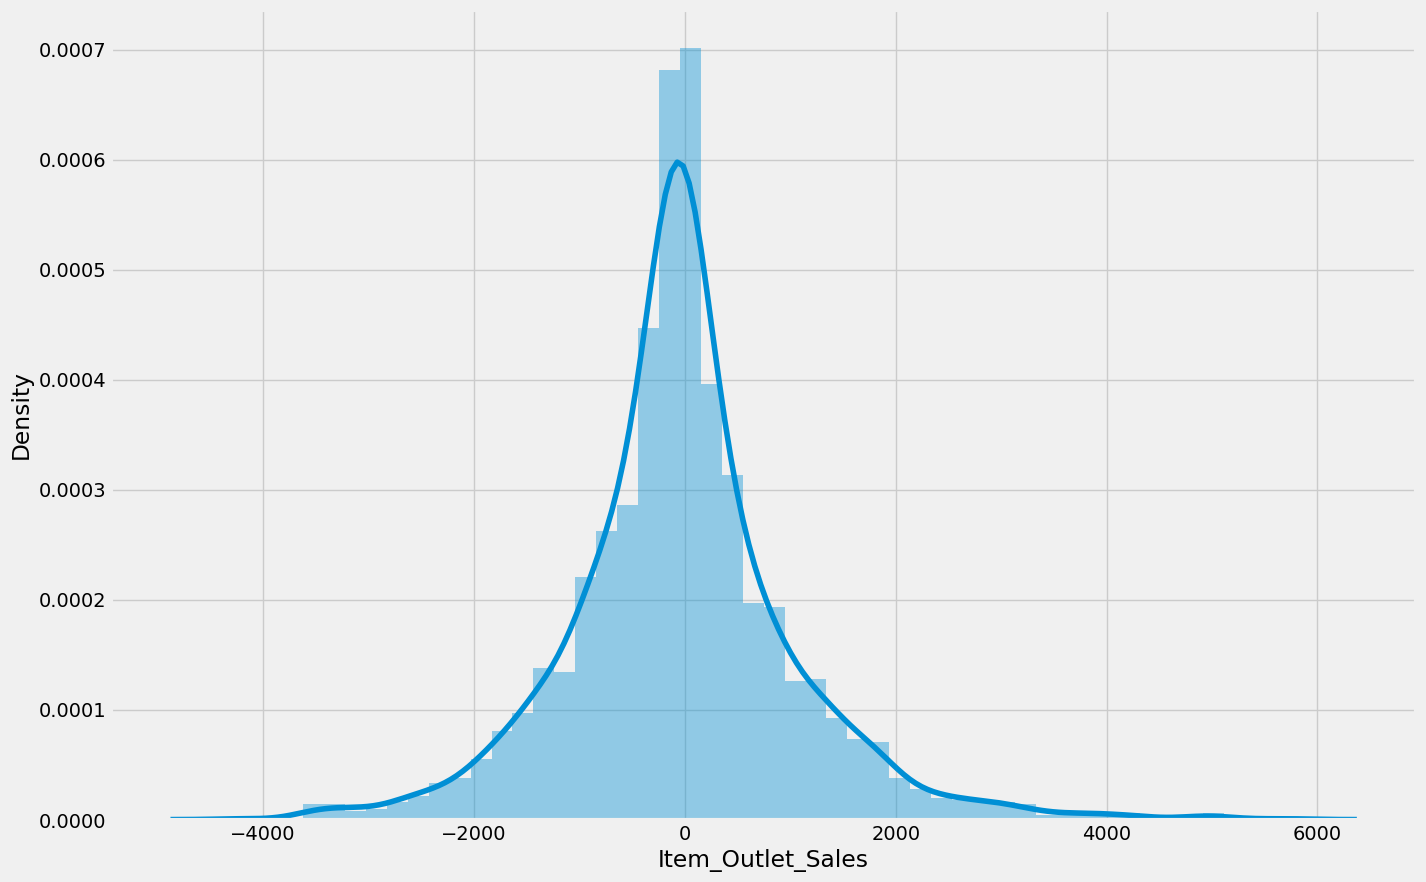

In [ ]:
predictions = best_rf.predict(X_test)
sns.distplot(y_test - predictions)
plt.show()

Passing some of the list of parameters for the <span style ='color:green'> LGBM Regressor </span> Model to run with Randomized Search CV Algorithm

Fitting The <span style ='color:green'>LGBM Regressor</span> Model with the above mentioned parameters in the RandomizedSearchCV Algorithm and displaying the Best Parameters, Best Score and R2 Score between test dependent variable and predicted dependent variable

In [ ]:
from scipy.stats import uniform, randint

lgb_param_dist = {
    'model__learning_rate': uniform(0.01, 0.19),
    'model__n_estimators': randint(100, 600),
    'model__max_depth': randint(3, 10),
    'model__num_leaves': randint(15, 64),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4)
}

best_lgb = evaluate("LightGBM-Tuned",
                    LGBMRegressor(random_state=42, verbose=-1),
                    param_grid=lgb_param_dist)


LightGBM-Tuned best params: {'model__colsample_bytree': np.float64(0.996884623716487), 'model__learning_rate': np.float64(0.12732148682926614), 'model__max_depth': 4, 'model__n_estimators': 121, 'model__num_leaves': 58, 'model__subsample': np.float64(0.6092249700165663)}
LightGBM-Tuned     R2=0.5911 | RMSE=1070.22 | MAE=745.73


Visualizing the data distribution of the dependent test variable , predicted dependent variable of the LGBM Regressor Model against the density distribution using Seaborn Distplot

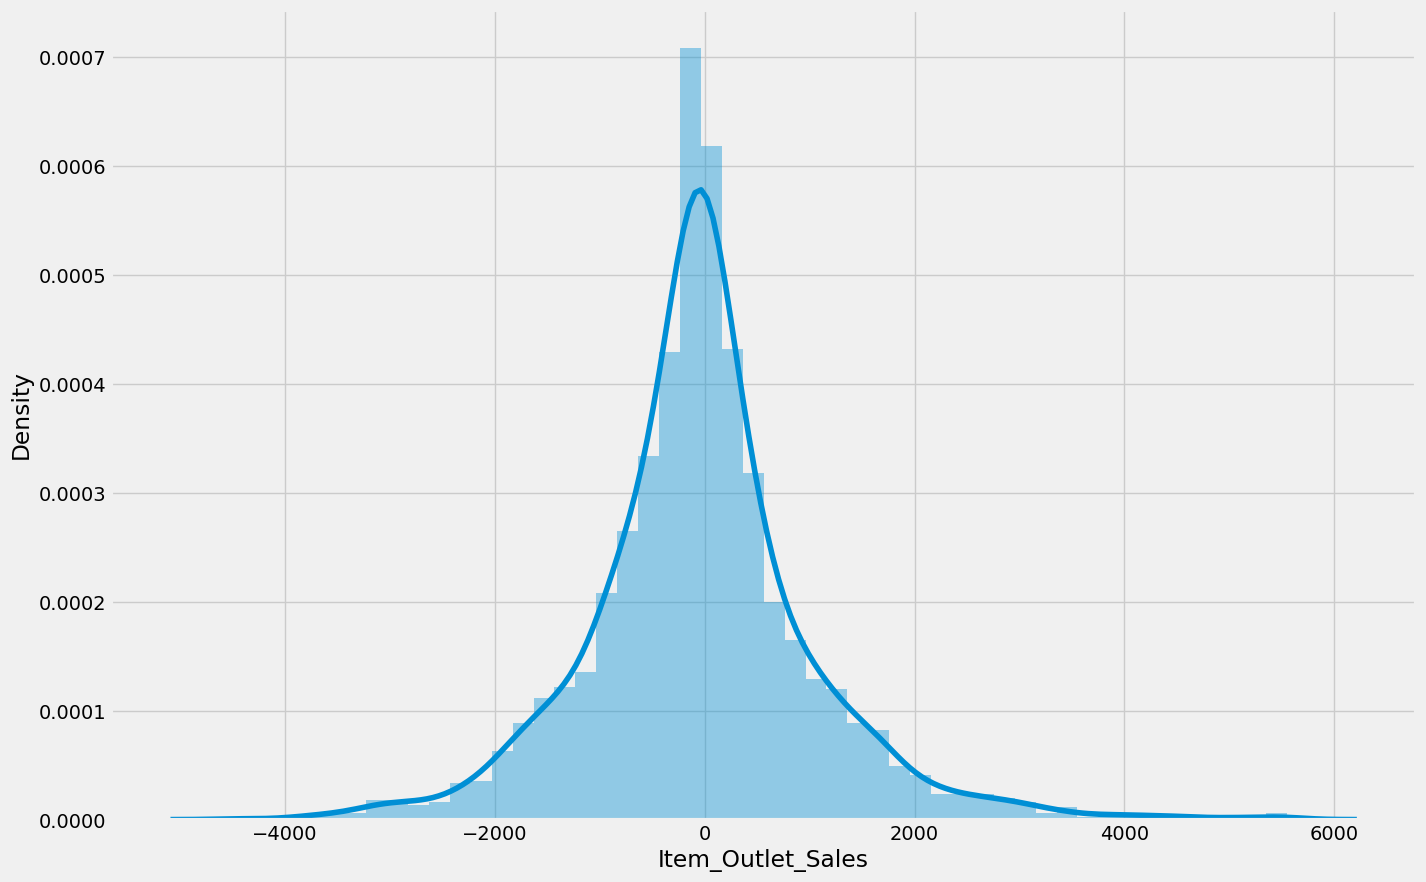

In [ ]:
predictions = best_lgb.predict(X_test)
sns.distplot(y_test-predictions)
plt.show()

Passing some of the list of parameters for the <span style ='color:green'> XGB Regressor </span> Model to run with Randomized Search CV Algorithm

Fitting The <span style ='color:green'>XGB Regressor</span> Model with the above mentioned parameters in the RandomizedSearchCV Algorithm and displaying the Best Parameters, Best Score and R2 Score between test dependent variable and predicted dependent variable

In [ ]:
from scipy.stats import uniform, randint

xgb_param_dist = {
    'model__learning_rate': uniform(0.01, 0.15),
    'model__max_depth': randint(3, 8),
    'model__n_estimators': randint(100, 600),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__gamma': uniform(0, 0.5)
}

best_xgb = evaluate("XGBoost-Tuned",
                    XGBRegressor(random_state=42, verbosity=0),
                    param_grid=xgb_param_dist)


XGBoost-Tuned best params: {'model__colsample_bytree': np.float64(0.608233797718321), 'model__gamma': np.float64(0.48495492608099716), 'model__learning_rate': np.float64(0.13486639612006326), 'model__max_depth': 4, 'model__n_estimators': 291, 'model__subsample': np.float64(0.996884623716487)}
XGBoost-Tuned      R2=0.5645 | RMSE=1104.42 | MAE=771.92


Visualizing the data distribution of the dependent test variable , predicted dependent variable of the XGB Regressor Model against the density distribution using Seaborn Distplot

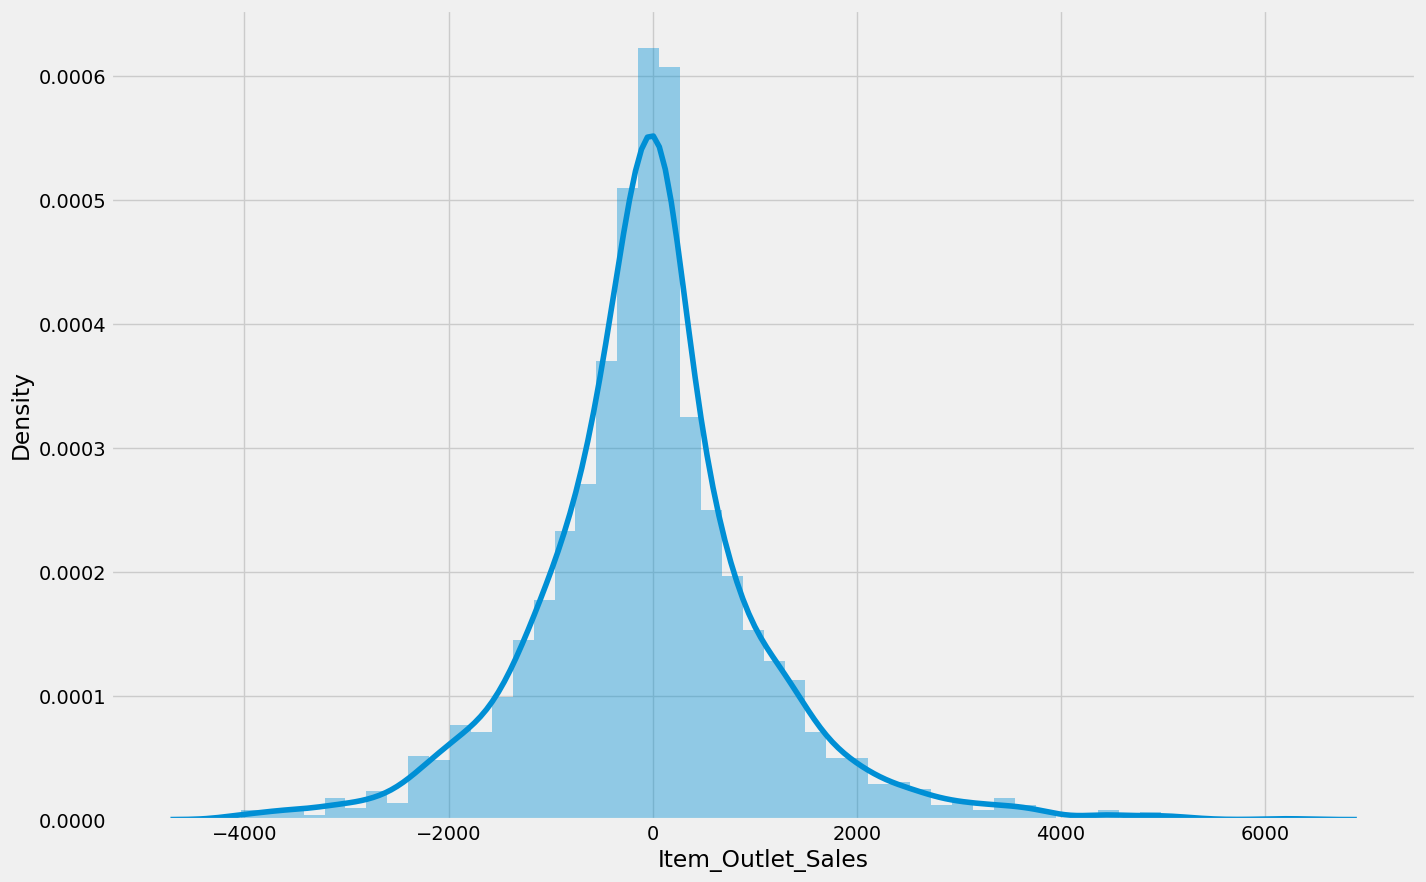

In [ ]:
predictions = best_xgb.predict(X_test)
sns.distplot(y_test-predictions)
plt.show()

Passing some of the list of parameters for the <span style ='color:green'> CatBoost Regressor </span> Model to run with Randomized Search CV Algorithm

Fitting The <span style ='color:green'>CatBoost Regressor</span> Model with the above mentioned parameters in the RandomizedSearchCV Algorithm and displaying the Best Parameters, Best Score and R2 Score between test dependent variable and predicted dependent variable

In [ ]:
from scipy.stats import uniform, randint

cat_param_dist = {
    'model__depth': randint(3, 8),
    'model__learning_rate': uniform(0.02, 0.12),
    'model__n_estimators': randint(200, 600),
    'model__l2_leaf_reg': uniform(1, 9)
}

best_cat = evaluate("CatBoost-Tuned",
                    CatBoostRegressor(random_state=42, verbose=0),
                    param_grid=cat_param_dist)


CatBoost-Tuned best params: {'model__depth': 4, 'model__l2_leaf_reg': np.float64(2.636424704863906), 'model__learning_rate': np.float64(0.042008541182412054), 'model__n_estimators': 513}
CatBoost-Tuned     R2=0.5983 | RMSE=1060.79 | MAE=740.06


Visualizing the data distribution of the dependent test variable , predicted dependent variable of the CatBoost Regressor Model against the density distribution using Seaborn Distplot

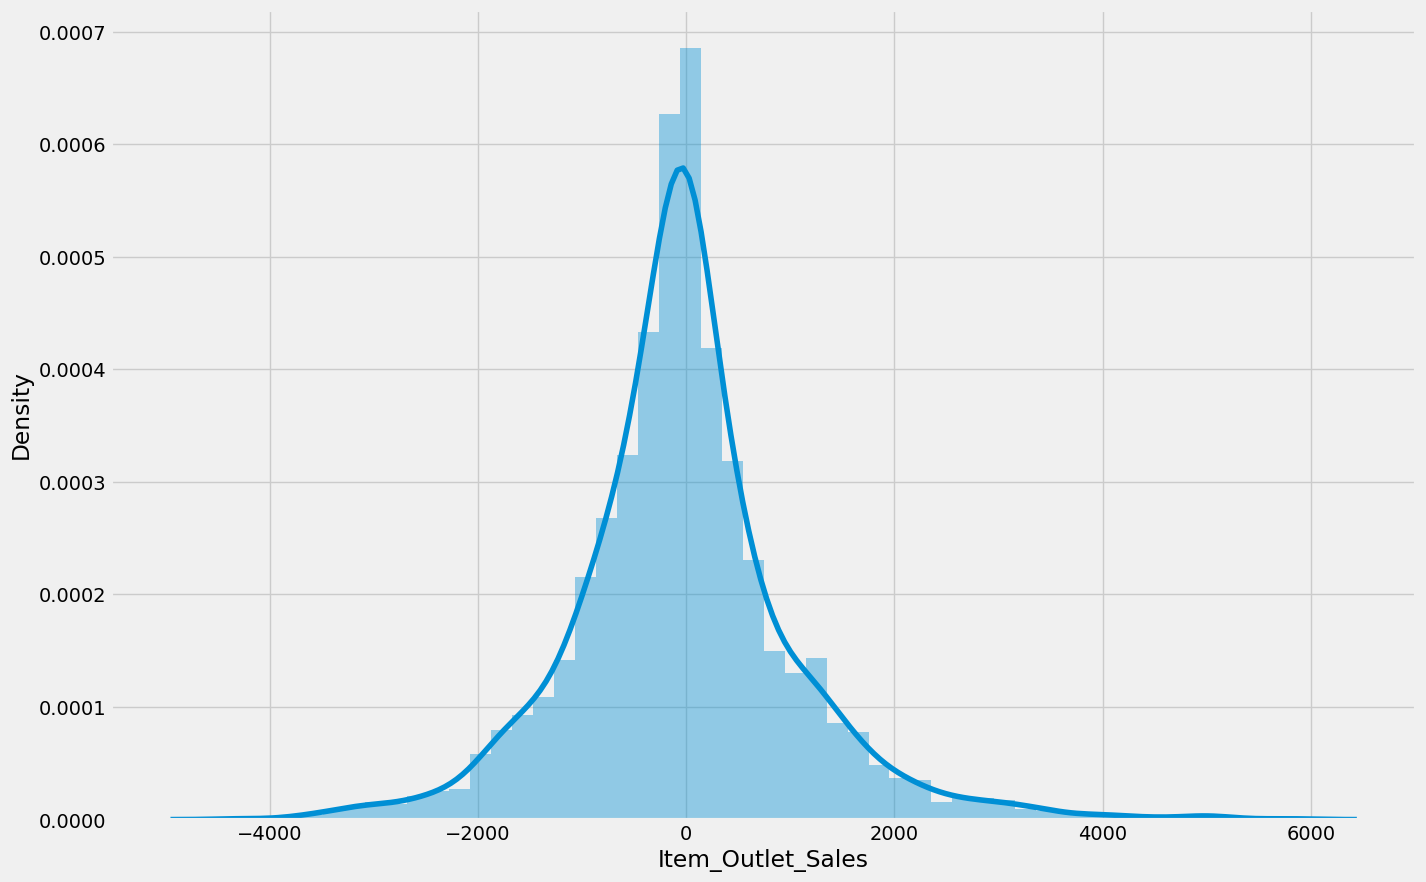

In [ ]:
predictions = best_cat.predict(X_test)
sns.distplot(y_test-predictions)
plt.show()

Fitting The <span style ='color:green'>CatBoost Regressor</span> Model with the best params got from the Randomized SearchCV and predicting the test dependent data to verify the r2 score with the r2 score got from Randomized SearchCV

In [ ]:
cat = CatBoostRegressor(learning_rate = 0.08941885942788719, max_depth = 2, n_estimators = 109,
                        subsample = 0.6676443346250142, verbose = 0)

# Create copies of X_train and X_test for direct CatBoost fit to avoid modifying original dataframes
X_train_for_cat = X_train.copy()
X_test_for_cat = X_test.copy()

# Impute missing values in 'Outlet_Size' (categorical) with the most frequent value from training data
most_frequent_outlet_size = X_train_for_cat['Outlet_Size'].mode()[0]
X_train_for_cat['Outlet_Size'].fillna(most_frequent_outlet_size, inplace=True)
X_test_for_cat['Outlet_Size'].fillna(most_frequent_outlet_size, inplace=True)

# Impute missing values in 'Item_Weight' (numerical) with the median from training data
median_item_weight = X_train_for_cat['Item_Weight'].median()
X_train_for_cat['Item_Weight'].fillna(median_item_weight, inplace=True)
X_test_for_cat['Item_Weight'].fillna(median_item_weight, inplace=True)

cat.fit(X_train_for_cat, y_train, cat_features=cat_cols)
predictions = cat.predict(X_test_for_cat)
print('R2 score : ',r2_score(y_test,predictions))

R2 score :  0.6048614997199262


## Test

Create the pickle file of the model with the highest r2 score with the name Model

In [ ]:
pickle.dump(cat,open('Model.pkl','wb'))

Loading the pickle file and predicting the dependent variable for the whole data and getting the r2 score between the predicted dependent variable and dependent variable

In [ ]:
model = pickle.load(open('Model.pkl','rb'))

# Create a copy of x for imputation
x_for_pred = x.copy()

# Impute missing values in 'Outlet_Size' (categorical) with the most frequent value
# The most frequent value should be consistent with training data (which was 'Medium')
most_frequent_outlet_size = 'Medium'
x_for_pred['Outlet_Size'].fillna(most_frequent_outlet_size, inplace=True)

# Impute missing values in 'Item_Weight' (numerical) with the median
# The median value should be consistent with training data (which was 12.65)
median_item_weight = 12.65
x_for_pred['Item_Weight'].fillna(median_item_weight, inplace=True)

fpred = model.predict(x_for_pred)
print('R2 Score of Full Data : ',r2_score(y,fpred))

R2 Score of Full Data :  0.6047366958000139
